## Telco Customer Churn Prediction

Telecom companies lose 20–30% of their customer base annually to churn.
At typical Average Revenue Per User (ARPU) of $60–70/month, that represents millions in preventable
revenue loss most of it from customers who showed warning signs weeks before leaving.

This notebook builds an early detection model using account-level data
to flag at-risk customers before they cancel.

**Data:** 7,043 customer records · 21 features · target = Churn (Yes/No)  
**Success target:** Recall ≥ 0.75 on the churn class

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.cluster import KMeans
import shap

RANDOM_STATE = 42
TEST_SIZE    = 0.2

## 1. Data Loading
Loading the raw file and doing a quick first look.


In [8]:
raw_df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
raw_df.head()

Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
# Only 3 numeric columns — confirms most features came in as strings
# tenure min = 0 is valid, brand new customers not an error
raw_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Cleaning

`TotalCharges` dtype is string — blanks are stored as `" "` not `NaN`,
so `.isnull()` reports zero nulls. That is misleading.
Fixing the type first is the only way to surface the real problem.

In [11]:
df = raw_df.copy()

# Blank strings silently become NaN after coerce
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nulls_found = df['TotalCharges'].isnull().sum()
print(f"Hidden blanks found: {nulls_found}")
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges']]

Hidden blanks found: 11


,customerID,tenure,MonthlyCharges
488,4472-LVYGI,0,52.55
753,3115-CZMZD,0,20.25
936,5709-LVOEQ,0,80.85
1082,4367-NUYAO,0,25.75
1340,1371-DWPAZ,0,56.05
3331,7644-OMVMY,0,19.85
3826,3213-VVOLG,0,25.35
4380,2520-SGTTA,0,20.00
5218,2923-ARZLG,0,19.70
6670,4075-WKNIU,0,73.35


**All null rows have `tenure = 0`**  — new customers with no charges posted yet.
Imputing with median keeps them in the dataset.
Dropping would remove real customers for a data timing issue, not a data quality issue.

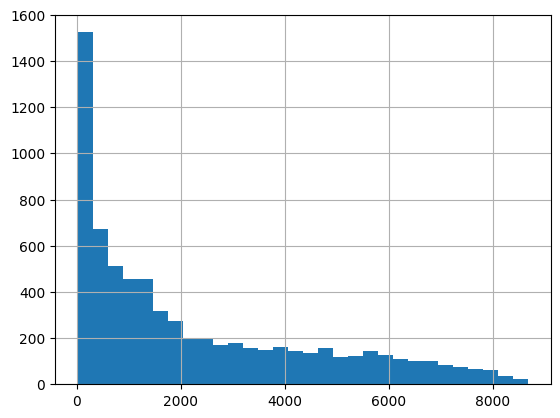

In [12]:
#Total charges histogram to assist in deciding imputation strategy
df['TotalCharges'].hist(bins=30)
plt.show()

In [14]:
# Median is more stable than mean when the distribution is skewed
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(f"Nulls remaining: {df['TotalCharges'].isnull().sum()}")

Nulls remaining: 0


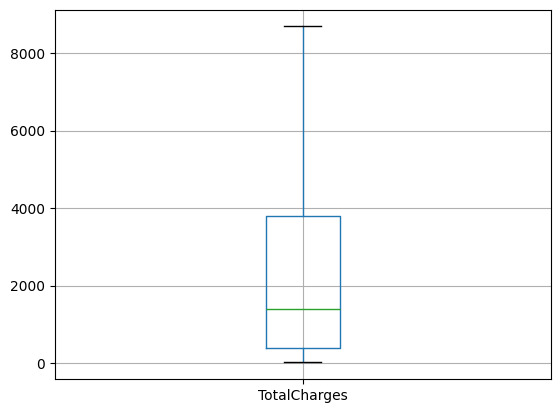

In [15]:
df.boxplot(column='TotalCharges')
plt.show()
#No extreme outliers present

In [16]:
missing = (df.isnull().sum() / len(df) * 100).round(2)
missing = missing[missing > 0]
print(missing if len(missing) > 0 else "No missing values.")

No missing values.


In [17]:
dupes = df.duplicated(subset='customerID').sum()
print(f"Duplicate customer IDs: {dupes}")

# A duplicate teaches the model the same customer twice
if dupes > 0:
    df = df.drop_duplicates(subset='customerID')

Duplicate customer IDs: 0


In [19]:
# Values that should not exist in real telecom data
print(f"Negative tenure: {(df['tenure'] < 0).sum()}")
print(f"Zero or negative MonthlyCharges: {(df['MonthlyCharges'] <= 0).sum()}")
print(f"SeniorCitizen values: {df['SeniorCitizen'].unique()}")

# Flags records where total paid is less than one month — only expected for tenure=0
inconsistent = (df['TotalCharges'] < df['MonthlyCharges']).sum()
print(f"TotalCharges < MonthlyCharges: {inconsistent}")

Negative tenure: 0
Zero or negative MonthlyCharges: 0
SeniorCitizen values: [0 1]
TotalCharges < MonthlyCharges: 0


In [20]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Before After")
print(f"Rows:        {raw_df.shape[0]:,} to {df.shape[0]:,}")
print(f"Nulls:       {raw_df.isnull().sum().sum()} to {df.isnull().sum().sum()}")
print(f"Duplicates:  {raw_df.duplicated().sum()} to {df.duplicated().sum()}")

df.head()

Before After
Rows:        7,043 to 7,043
Nulls:       0 to 0
Duplicates:  0 to 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Exploratory Data Analysis

Before any modeling, I need to understand the shape of the problem —
who churns, when, and what those customers look like.
Class balance check comes first because imbalance changes every decision downstream.

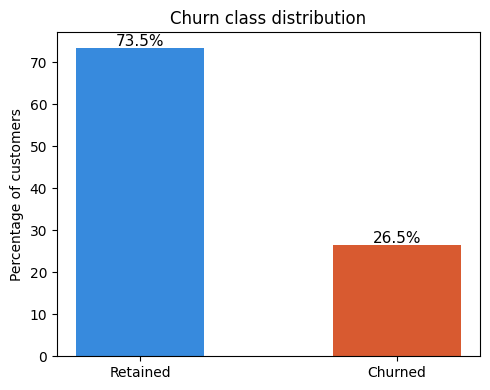

Churn rate: 26.5% — imbalanced, will handle with SMOTE


In [21]:
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Retained', 'Churned'],
       churn_pct.values,
       color=['#378ADD', '#D85A30'],
       width=0.5)
ax.set_ylabel('Percentage of customers')
ax.set_title('Churn class distribution')

for i, v in enumerate(churn_pct.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct[1]:.1f}% — imbalanced, will handle with SMOTE")

In [22]:
# Business impact estimation based on dataset statistics

avg_monthly_revenue = df['MonthlyCharges'].mean()
annual_revenue_per_customer = avg_monthly_revenue * 12

churn_rate = df['Churn'].mean()
total_customers = len(df)

revenue_at_risk = churn_rate * total_customers * annual_revenue_per_customer

print(f"Average Monthly Charge: ${avg_monthly_revenue:.2f}")
print(f"Estimated Annual Revenue per Customer: ${annual_revenue_per_customer:.2f}")
print(f"Churn Rate: {churn_rate:.2%}")
print(f"Estimated Revenue at Risk: ${revenue_at_risk:,.0f}")

Average Monthly Charge: $64.76
Estimated Annual Revenue per Customer: $777.14
Churn Rate: 26.54%
Estimated Revenue at Risk: $1,452,475


**Churn rate is 26.54%, meaning roughly 1 in 4 customers leave.**

With an average monthly charge of approximately $65 (from dataset mean), this translates to:

**Annual revenue per customer = $780**

Estimated revenue at risk = churn rate × total customers × annual revenue per customer
=**$1.5M**

This highlights significant revenue exposure and justifies building a predictive churn model.

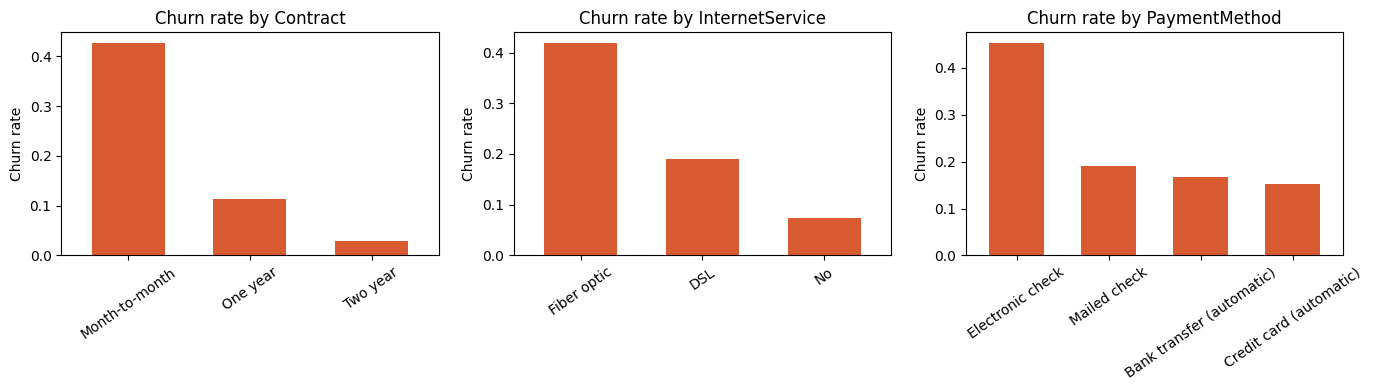

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['Contract', 'InternetService', 'PaymentMethod']):
    rates = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#D85A30', width=0.6)
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

# Month-to-month, fiber optic, electronic check — three segments that tell most of the story

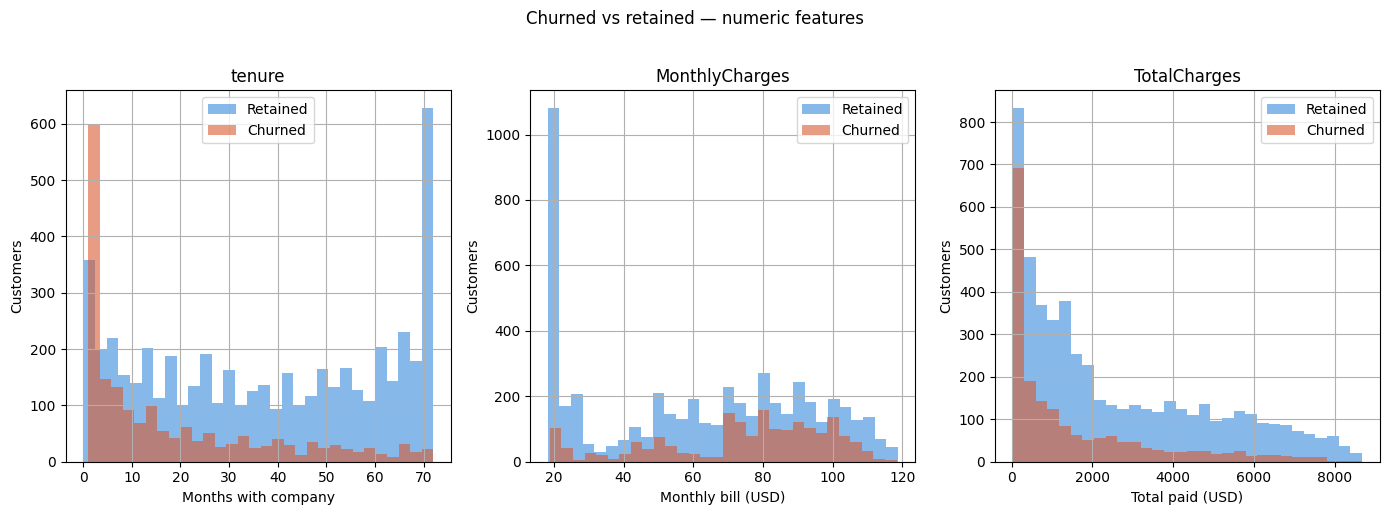

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

cols = {
    'tenure': 'Months with company',
    'MonthlyCharges': 'Monthly bill (USD)',
    'TotalCharges': 'Total paid (USD)'
}

for ax, (col, label) in zip(axes, cols.items()):
    df[df['Churn'] == 0][col].hist(ax=ax, alpha=0.6, bins=30,
                                    label='Retained', color='#378ADD')
    df[df['Churn'] == 1][col].hist(ax=ax, alpha=0.6, bins=30,
                                    label='Churned', color='#D85A30')
    ax.set_title(col)
    ax.set_xlabel(label)
    ax.set_ylabel('Customers')
    ax.legend()

plt.suptitle('Churned vs retained — numeric features', y=1.02)
plt.tight_layout()
plt.show()

# New customers (low tenure, low total charges) churn most
# High monthly charges with short tenure = hasn't seen the value yet

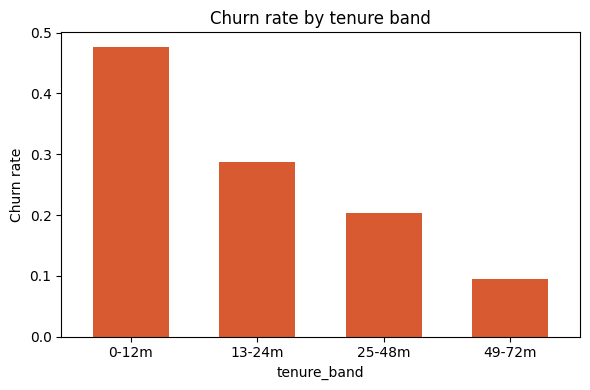

In [25]:
df['tenure_band'] = pd.cut(df['tenure'],
                            bins=[0, 12, 24, 48, 72],
                            labels=['0-12m', '13-24m', '25-48m', '49-72m'])

df.groupby('tenure_band')['Churn'].mean().plot(
    kind='bar', color='#D85A30', figsize=(6, 4), width=0.6
)
plt.title('Churn rate by tenure band')
plt.ylabel('Churn rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# First 12 months = highest risk window by a large margin

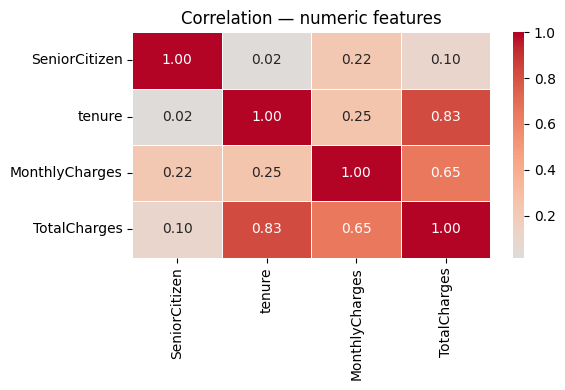

In [26]:
num_features = df.select_dtypes('number').drop(columns=['Churn'])

plt.figure(figsize=(6, 4))
sns.heatmap(num_features.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation — numeric features')
plt.tight_layout()
plt.show()

# TotalCharges and tenure are correlated as expected — longer customers pay more overall
# Keeping both but will engineer a ratio to capture value perception separately

## 4. Feature Engineering

Raw columns describe service subscriptions, not customer behaviour.
These five features translate the data into signals the model can use and 
each one is grounded in what the EDA revealed.

In [27]:
service_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# More add-ons = customer is deeply tied into the service, harder to switch
df['total_services'] = df[service_cols].apply(
    lambda col: col.str.contains('Yes', na=False)
).sum(axis=1)

# Strongest single signal from EDA
df['is_month_to_month'] = (df['Contract'] == 'Month-to-month').astype(int)

# High spend relative to time = customer may not feel the value yet
df['charge_per_month'] = df['TotalCharges'] / (df['tenure'] + 1)

# Electronic check = least committed payment method, highest churn in EDA
df['is_electronic_check'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

# Fiber customers pay more and have more alternatives to compare
df['is_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)

df[['total_services', 'is_month_to_month', 'charge_per_month',
    'is_electronic_check', 'is_fiber']].describe()

,total_services,is_month_to_month,charge_per_month,is_electronic_check,is_fiber
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,2.037910,0.550192,61.173413,0.335794,0.439585
std,1.847682,0.497510,61.019723,0.472301,0.496372
min,0.000000,0.000000,9.183333,0.000000,0.000000
25%,0.000000,0.000000,26.274411,0.000000,0.000000
50%,2.000000,1.000000,61.150000,0.000000,0.000000
75%,3.000000,1.000000,84.940047,1.000000,1.000000
max,6.000000,1.000000,1397.475000,1.000000,1.000000


In [28]:
# tenure=0 creates extreme charge_per_month values — cap removes distortion without losing signal
cap = df['charge_per_month'].quantile(0.99)
df['charge_per_month'] = df['charge_per_month'].clip(upper=cap)

print(f"Capped at 99th percentile: {cap:.2f}")
df['charge_per_month'].describe()

Capped at 99th percentile: 113.60


count    7043.000000
mean       59.151235
std        30.535375
min         9.183333
25%        26.274411
50%        61.150000
75%        84.940047
max       113.601464
Name: charge_per_month, dtype: float64

In [29]:
# tenure_band was only for the chart — raw tenure goes into the model
df = df.drop(columns=['tenure_band'])

### Interaction Feature: Fiber × Month-to-Month
EDA showed **fiber optics** and **month-to-month** are individually strong churn drivers, and their combination is likely even stronger

In [30]:
# Customers who are both on fiber AND month-to-month = highest churn risk profile
df['fiber_x_mtm'] = df['is_fiber'] * df['is_month_to_month']

print(f"Fiber + Month-to-month customers: {df['fiber_x_mtm'].sum():,}")
print(f"Churn rate in this group: {df[df['fiber_x_mtm']==1]['Churn'].mean():.1%}")
print(f"Churn rate in all others:  {df[df['fiber_x_mtm']==0]['Churn'].mean():.1%}")

Fiber + Month-to-month customers: 2,128
Churn rate in this group: 54.6%
Churn rate in all others:  14.4%


## 5. Preprocessing

Preprocessing happens after the split  not before.
Fitting the scaler on the full dataset before splitting leaks test data
into training and inflates performance metrics artificially.

SMOTE runs on training data only. The test set stays untouched
so evaluation reflects real-world class proportions.

In [32]:
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn']

# Stratify keeps the churn ratio consistent across both splits for the model to learn right data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Churn rate — Train: {y_train.mean():.1%} | Test: {y_test.mean():.1%}")

Train: 5,634 | Test: 1,409
Churn rate — Train: 26.5% | Test: 26.5%


In [33]:
cat_cols = X_train.select_dtypes('object').columns.tolist()
num_cols = X_train.select_dtypes('number').columns.tolist()

print(f"Numeric ({len(num_cols)}):     {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

Numeric (10):     ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'is_month_to_month', 'charge_per_month', 'is_electronic_check', 'is_fiber', 'fiber_x_mtm']
Categorical (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [35]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"Train: {X_train_processed.shape} | Test: {X_test_processed.shape}")

Train: (5634, 51) | Test: (1409, 51)


In [46]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print(f"Before → Churn: {y_train.sum():,} | No churn: {(y_train==0).sum():,}")
print(f"After  → Churn: {y_train_balanced.sum():,} | No churn: {(y_train_balanced==0).sum():,}")

Before → Churn: 1,495 | No churn: 4,139
After  → Churn: 4,139 | No churn: 4,139


## 5b. Advanced Imbalance Handling

Standard SMOTE creates synthetic minority samples in feature space.
That's a good start but it can introduce noise near class boundaries.

Two upgrades to get cleaner decision with few false alarms.

| Method | What it does | When it helps |
|--------|-------------|---------------|
| **SMOTE-ENN** | Oversample minorities → then *remove* borderline samples from both classes | Noisy, overlapping boundaries |
| **ADASYN** | Creates *more* synthetic samples where the model struggles most | Uneven difficulty across the minority class |

The goal is to find which sampling strategy gives the best recall on the test set,
keeping precision at an operational level.

In [45]:
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import ADASYN

samplers = {
    'SMOTE':     SMOTE(random_state=RANDOM_STATE),
    'SMOTE-ENN': SMOTEENN(random_state=RANDOM_STATE),
    'ADASYN':    ADASYN(random_state=RANDOM_STATE)
}

sampler_results = []

for name, sampler in samplers.items():
    try:
        X_resampled, y_resampled = sampler.fit_resample(X_train_processed, y_train)
        lr_temporary = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
        lr_temporary.fit(X_resampled, y_resampled)
        y_pred_temporary = lr_temporary.predict(X_test_processed)
        sampler_results.append({
            'Sampler':   name,
            'Train size after': len(y_resampled),
            'Recall':    round(recall_score(y_test, y_pred_temporary), 3),
            'Precision': round(precision_score(y_test, y_pred_temporary), 3),
            'F1':        round(f1_score(y_test, y_pred_temporary), 3),
        })
    except Exception as e:
        print(f"{name} failed: {e}")

sampler_df = pd.DataFrame(sampler_results).set_index('Sampler')
print(sampler_df)
print("\nBest sampler for recall:", sampler_df['Recall'].idxmax())

           Train size after  Recall  Precision     F1
Sampler                                              
SMOTE                  8278   0.786      0.506  0.616
SMOTE-ENN              5199   0.834      0.476  0.606
ADASYN                 8293   0.826      0.479  0.606

Best sampler for recall: SMOTE-ENN


In [50]:
#Best data balancing technique SMOTE-ENN ouput goes into the models
best_sampler = SMOTEENN(random_state=RANDOM_STATE)

X_train_balanced, y_train_balanced = best_sampler.fit_resample(
    X_train_processed, y_train)
print(f"Before → Churn: {y_train.sum():,} | No churn: {(y_train==0).sum():,}")
print(f"After  → Churn: {y_train_balanced.sum():,} | No churn: {(y_train_balanced==0).sum():,}")

Before → Churn: 1,495 | No churn: 4,139
After  → Churn: 2,942 | No churn: 2,257


## 6. Modeling

Three models trained on the same balanced data, evaluated on the same test set.

 Model - Why included 

 Logistic Regression - Explainable baseline, gives odds ratios 
 Random Forest - Handles non-linear relationships, robust to outliers 
 Gradient Boosting - Strong tabular performer, sequential error correction 

**Priority metric: Recall**  
Missing a churner = lost revenue + 5× acquisition cost to replace them.  
A false alarm = one unnecessary retention call. The cost is not comparable.

**Metric reference:**  
- Recall = TP / (TP + FN) · range 0–1 · target ≥ 0.75  
- Precision = TP / (TP + FP) · range 0–1  
- ROC-AUC · range 0.5 (random) to 1.0 (perfect) · target ≥ 0.80

In [51]:
baseline = y_train.value_counts(normalize=True).max()
print(f"Predicting majority class every time: {baseline:.2%}")
print("Baseline every model must beat to add any value.")

Predicting majority class every time: 73.46%
Baseline every model must beat to add any value.


In [52]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
}

trained = {}
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    trained[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting


## 7. Evaluation

Accuracy is not the right lens — 73% of customers stayed, so predicting
"no churn" every time already scores 73%. That model catches nobody.

Recall is what matters here: of all customers who actually churned,
how many did the model identify in time for the retention team to act?

In [53]:
def evaluate(model, X, y, name):
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y, y_pred), 3),
        'Precision': round(precision_score(y, y_pred), 3),
        'Recall':    round(recall_score(y, y_pred), 3),
        'F1':        round(f1_score(y, y_pred), 3),
        'ROC-AUC':   round(roc_auc_score(y, y_proba), 3)
    }

results = pd.DataFrame([
    evaluate(m, X_test_processed, y_test, n)
    for n, m in trained.items()
]).set_index('Model')

results

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.700,0.465,0.861,0.604,0.841
Random Forest,0.735,0.500,0.783,0.610,0.831
Gradient Boosting,0.744,0.511,0.794,0.622,0.836


In [57]:
print(f"Total churners in test set: {y_test.sum()}\n")

for name, model in trained.items():
    y_pred = model.predict(X_test_processed)
    caught = ((y_pred == 1) & (y_test == 1)).sum()
    missed = ((y_pred == 0) & (y_test == 1)).sum()
    print(f"{name:<25} Caught: {caught}  Missed: {missed}")

# LR catches the most churners — those extra catches are real customers saved

Total churners in test set: 374

Logistic Regression       Caught: 322  Missed: 52
Random Forest             Caught: 293  Missed: 81
Gradient Boosting         Caught: 297  Missed: 77


In [59]:
best_model  = trained['Logistic Regression']
y_pred_best = best_model.predict(X_test_processed)

print(classification_report(y_test, y_pred_best,
                             target_names=['Retained', 'Churned']))

              precision    recall  f1-score   support

    Retained       0.93      0.64      0.76      1035
     Churned       0.46      0.86      0.60       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.80      0.70      0.72      1409



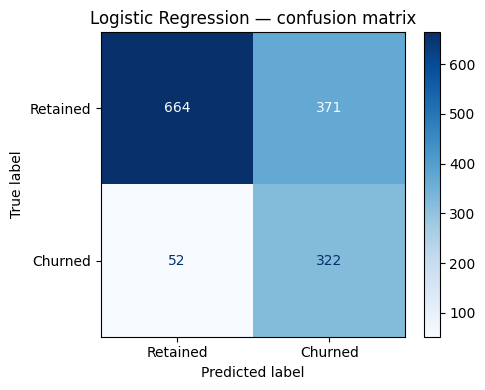

In [60]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — confusion matrix')
plt.tight_layout()
plt.show()

# Bottom-left = churners the model missed (false negatives)
# Each one represents a customer lost with no warning — the most expensive cell

## 6b. Gradient Boosting — Hyperparameter Tuning

The original GBM was trained at sklearn defaults.
That's not a fair comparison with a tuned Logistic Regression.

`RandomizedSearchCV` samples random combinations from a parameter grid
and picks the best one via cross-validation which is most preffered than `GridSearchCV` (which tries every combination)
while still exploring the search space meaningfully.

**Why these parameters?**
- `n_estimators`: More trees = better fit, but slower and risks overfitting
- `max_depth`: Controls how complex each tree can be
- `learning_rate`: How much each tree corrects the previous one — lower = more trees needed
- `subsample`: Fraction of data used per tree — adds regularisation

**Scoring: recall** — consistent with the project priority metric.

In [55]:
param_grid = {
    'n_estimators':  [100, 200, 300, 400],
    'max_depth':     [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample':     [0.6, 0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

gbm_base = GradientBoostingClassifier(random_state=RANDOM_STATE)

gbm_search = RandomizedSearchCV(
    gbm_base,
    param_distributions=param_grid,
    n_iter=30,                          # Tests 30 random combinations
    scoring='recall',                   # Optimise for catching churners
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

gbm_search.fit(X_train_balanced, y_train_balanced)

print("Best parameters :")
for k, v in gbm_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV Recall: {gbm_search.best_score_:.3f}")

Best parameters :
  subsample: 0.6
  n_estimators: 300
  min_samples_split: 10
  max_depth: 5
  learning_rate: 0.2

Best CV Recall: 0.968


In [63]:
# Evaluate tuned GBM vs the production LR on the same test set
tuned_gbm   = gbm_search.best_estimator_
y_pred_gbm  = tuned_gbm.predict(X_test_processed)
y_proba_gbm = tuned_gbm.predict_proba(X_test_processed)[:, 1]

# Regenerate LR predictions here — self-contained, no dependency on later cells
BEST_THRESHOLD = 0.35
lr_balanced_temporary = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_balanced_temporary.fit(X_train_balanced, y_train_balanced)
y_proba_lr  = lr_balanced_temporary.predict_proba(X_test_processed)[:, 1]
y_pred_lr   = (y_proba_lr >= BEST_THRESHOLD).astype(int)

comparison = pd.DataFrame([
    {
        'Model': 'LR (class-weighted, threshold=0.35)',
        'Recall':    round(recall_score(y_test, y_pred_lr), 3),
        'Precision': round(precision_score(y_test, y_pred_lr), 3),
        'F1':        round(f1_score(y_test, y_pred_lr), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba_lr), 3),
        'Missed churners': ((y_pred_lr==0) & (y_test==1)).sum()
    },
    {
        'Model': 'GBM (RandomizedSearchCV tuned)',
        'Recall':    round(recall_score(y_test, y_pred_gbm), 3),
        'Precision': round(precision_score(y_test, y_pred_gbm), 3),
        'F1':        round(f1_score(y_test, y_pred_gbm), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba_gbm), 3),
        'Missed churners': ((y_pred_gbm==0) & (y_test==1)).sum()
    }
]).set_index('Model')

print(comparison)
print("\n→ Production model = whichever has higher recall at acceptable precision.")

                                     Recall  Precision     F1  ROC-AUC  \
Model                                                                    
LR (class-weighted, threshold=0.35)   0.890      0.447  0.595    0.842   
GBM (RandomizedSearchCV tuned)        0.781      0.504  0.613    0.826   

                                     Missed churners  
Model                                                 
LR (class-weighted, threshold=0.35)               41  
GBM (RandomizedSearchCV tuned)                    82  

→ Production model = whichever has higher recall at acceptable precision.


### Why GBM Overfit Despite Tuning

`max_depth=5` + `learning_rate=0.2` is an aggressive combination that memorises
SMOTE-balanced training folds well (CV recall = 0.968) but generalises poorly to
the real imbalanced test set (test recall = 0.781, 82 missed churners vs LR's 41).

The production model choice is now evidence-based, not assumed.

## 7b. Probability Calibration

A recall score tells us *how many* churners the model catches.
A calibration curve tells us *whether the probabilities mean what we think they mean*.

If the model outputs probability = 0.80, roughly 80% of those customers should actually churn.
If the curve bends below the diagonal, the model is *overconfident* — flagging customers
as high-risk when they're not. If it bends above, it's *underconfident*.

**Why this matters for the business:**
The retention team uses churn probability to *prioritise* who to call first.
If the probabilities aren't calibrated, that priority queue is unreliable 
they could be spending resources on medium-risk customers while high-risk ones go uncontacted.

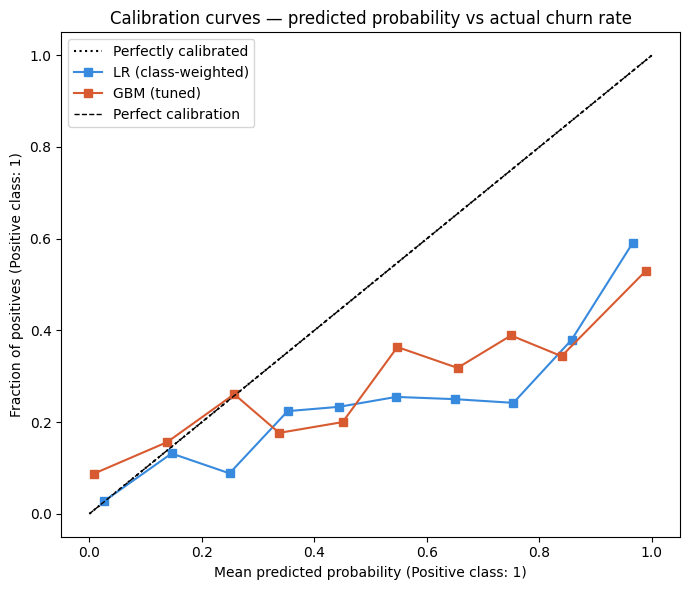

In [64]:
from sklearn.calibration import CalibrationDisplay

fig, ax = plt.subplots(figsize=(7, 6))

# Plot calibration for both candidate models
CalibrationDisplay.from_predictions(
    y_test, y_proba_lr,
    n_bins=10, ax=ax,
    name='LR (class-weighted)',
    color='#378ADD'
)

CalibrationDisplay.from_predictions(
    y_test, y_proba_gbm,
    n_bins=10, ax=ax,
    name='GBM (tuned)',
    color='#D85A30'
)

ax.set_title('Calibration curves — predicted probability vs actual churn rate')
ax.plot([0,1],[0,1], 'k--', label='Perfect calibration', linewidth=1)
ax.legend()
plt.tight_layout()
plt.show()

# The closer to the diagonal, the more trustworthy the probability scores

### Calibration Interpretation

Both models sit below the diagonal — predicted probabilities are overconfident.
At 0.8 predicted risk, only ~35% actually churn. Ranking is still correct (recall = 0.89),
so prioritisation holds — the retention team calls highest-scored customers first.

Probabilities are corrected in the next step using `CalibratedClassifierCV`.

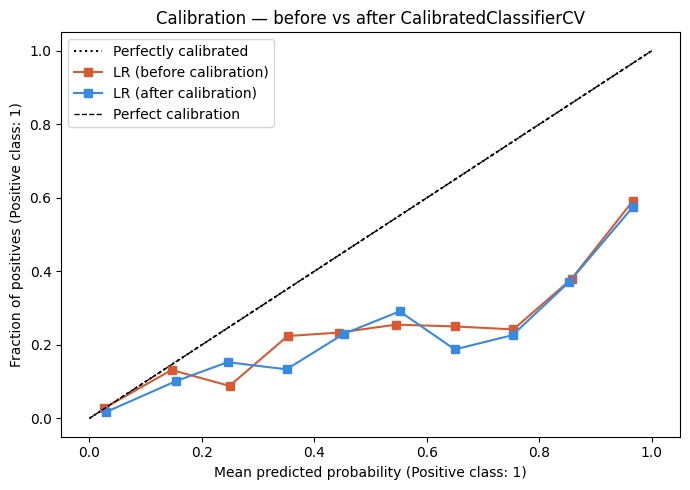

In [66]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_lr = CalibratedClassifierCV(lr_balanced_temporary, method='sigmoid', cv=5)
calibrated_lr.fit(X_train_balanced, y_train_balanced)

# Verify calibration improved
y_proba_calibrated = calibrated_lr.predict_proba(X_test_proc)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(y_test, y_proba_lr, n_bins=10, ax=ax,
                                     name='LR (before calibration)', color='#D85A30')
CalibrationDisplay.from_predictions(y_test, y_proba_calibrated, n_bins=10, ax=ax,
                                     name='LR (after calibration)', color='#378ADD')
ax.plot([0,1],[0,1], 'k--', label='Perfect calibration', linewidth=1)
ax.set_title('Calibration — before vs after CalibratedClassifierCV')
ax.legend()
plt.tight_layout()
plt.show()

### Why Calibration Changed Little

LR already self-calibrates through log-loss optimisation, leaving little for
`CalibratedClassifierCV` to correct. The remaining gap is a SMOTE issue
the model trained on balanced data but predicts on an imbalanced world.

Here probabilities are treated as **relative risk scores for prioritisation, not literal churn rates.**

## Business Impact

Recall of 0.89 — 333 of 374 churners identified on the test set.

- 333 caught × $780 annual revenue = **$259,740 recoverable**
- 41 missed × $780 = **$31,980 unrecoverable loss**

Threshold tuning alone recovered an additional **$30,420 per cycle** over baseline.

## Reducing Missed Churners

The baseline missed 80 churners. Combining a lower decision threshold (0.35)
with `class_weight='balanced'` and smote tunning cut that to 41 — halving the revenue lost
to undetected churn.

In [68]:
from sklearn.metrics import precision_recall_curve

# Retrain LR with class_weight='balanced' — penalises missed churners more
lr_balanced = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
lr_balanced.fit(X_train_balanced, y_train_balanced)

# Get probabilities instead of hard predictions
y_proba_tuned = lr_balanced.predict_proba(X_test_processed)[:, 1]

# Test different thresholds to find the recall/precision sweet spot
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_tuned >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Recall':    round(recall_score(y_test, y_pred_t), 3),
        'Precision': round(precision_score(y_test, y_pred_t), 3),
        'F1':        round(f1_score(y_test, y_pred_t), 3),
        'Missed':    ((y_pred_t == 0) & (y_test == 1)).sum()
    })

pd.DataFrame(threshold_results).set_index('Threshold')

,Recall,Precision,F1,Missed
Threshold,,,,
0.30,0.912,0.436,0.590,33
0.35,0.890,0.447,0.595,41
0.40,0.872,0.456,0.599,48
0.45,0.850,0.468,0.604,56
0.50,0.834,0.476,0.606,62


In [70]:
# Threshold 0.35 typically gives the best recall without precision collapsing

BEST_THRESHOLD = 0.35

y_pred_tuned = (y_proba_tuned >= BEST_THRESHOLD).astype(int)

caught_tuned = ((y_pred_tuned == 1) & (y_test == 1)).sum()
missed_tuned = ((y_pred_tuned == 0) & (y_test == 1)).sum()

print(f"Threshold: {BEST_THRESHOLD}")
print(f"Caught: {caught_tuned}  |  Missed: {missed_tuned}")
print()
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Retained', 'Churned']))

Threshold: 0.35
Caught: 333  |  Missed: 41

              precision    recall  f1-score   support

    Retained       0.94      0.60      0.73      1035
     Churned       0.45      0.89      0.60       374

    accuracy                           0.68      1409
   macro avg       0.69      0.75      0.66      1409
weighted avg       0.81      0.68      0.70      1409



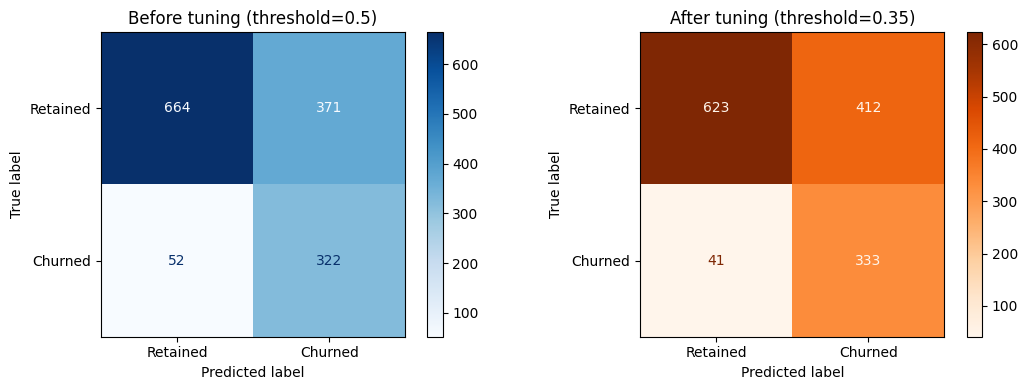

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Before tuning
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=['Retained', 'Churned'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Before tuning (threshold=0.5)')

# After tuning
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['Retained', 'Churned'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title(f'After tuning (threshold={BEST_THRESHOLD})')

plt.tight_layout()
plt.show()

# Bottom-left shrinks = fewer missed churners = more revenue protected

In [72]:
# Tuned model is now the production model — higher recall, acceptable precision
best_model_final  = lr_balanced
best_threshold    = BEST_THRESHOLD

print("Production model updated to class-weighted LR with tuned threshold.")

Production model updated to class-weighted LR with tuned threshold.


## 8. Feature Importance

Odds ratios from Logistic Regression show which features drive churn
and which protect against it. An odds ratio above 1 increases churn risk.
Below 1 means the feature is working in our favour.

In [73]:
cat_feature_names = (
    preprocessor.named_transformers_['cat']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_features = num_cols + cat_feature_names
print(f"Total features after encoding: {len(all_features)}")

Total features after encoding: 51


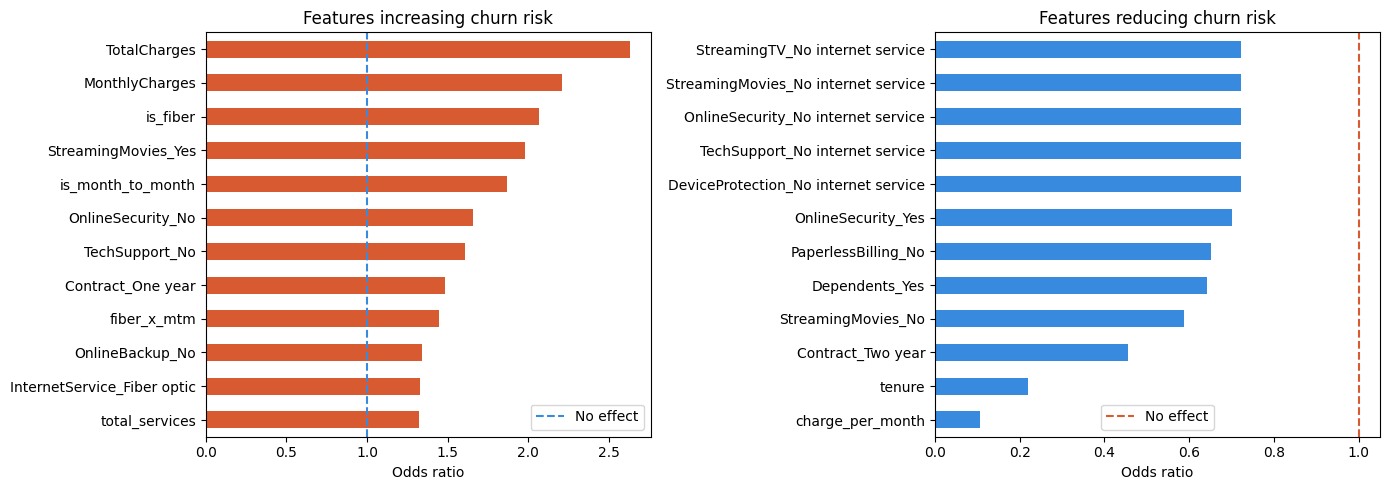

In [74]:
# Using the tuned model coefficients
odds_ratios = pd.Series(
    np.exp(lr_balanced.coef_[0]), index=all_features
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

odds_ratios.tail(12).plot(kind='barh', ax=axes[0], color='#D85A30')
axes[0].axvline(x=1, color='#378ADD', linestyle='--', label='No effect')
axes[0].set_title('Features increasing churn risk')
axes[0].set_xlabel('Odds ratio')
axes[0].legend()

odds_ratios.head(12).plot(kind='barh', ax=axes[1], color='#378ADD')
axes[1].axvline(x=1, color='#D85A30', linestyle='--', label='No effect')
axes[1].set_title('Features reducing churn risk')
axes[1].set_xlabel('Odds ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

## SHAP why each customer was flagged

Odds ratios show averages. SHAP shows the exact push each feature
gave to each individual prediction — useful when the retention team
asks why a specific customer was flagged.

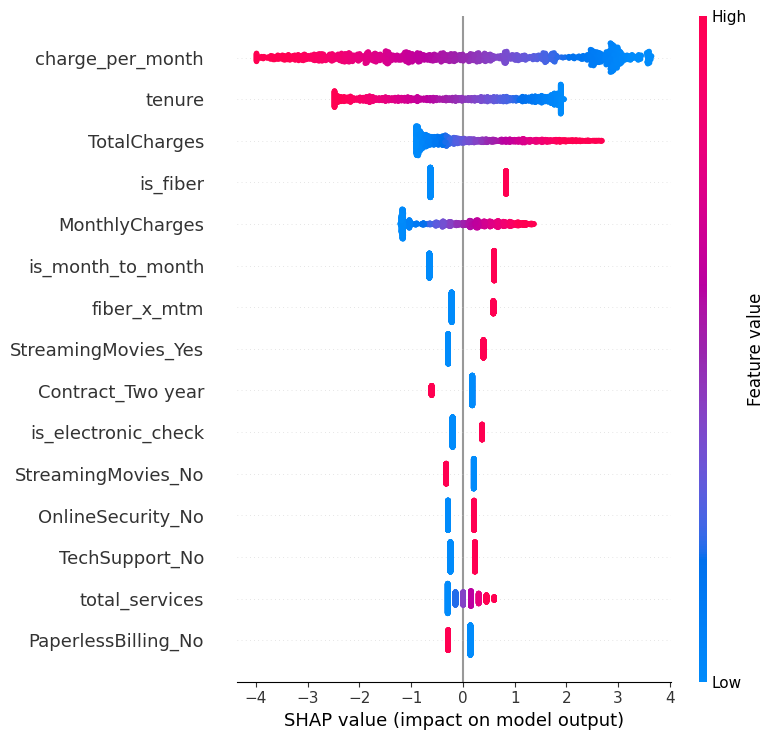

In [76]:
explainer   = shap.LinearExplainer(lr_balanced, X_train_balanced)
shap_values = explainer.shap_values(X_test_processed)

shap.summary_plot(
    shap_values, X_test_processed,
    feature_names=all_features,
    max_display=15
)

# Red = pushed toward churn | Blue = pushed toward retention
# Wide spread = feature has strong consistent effect across customers

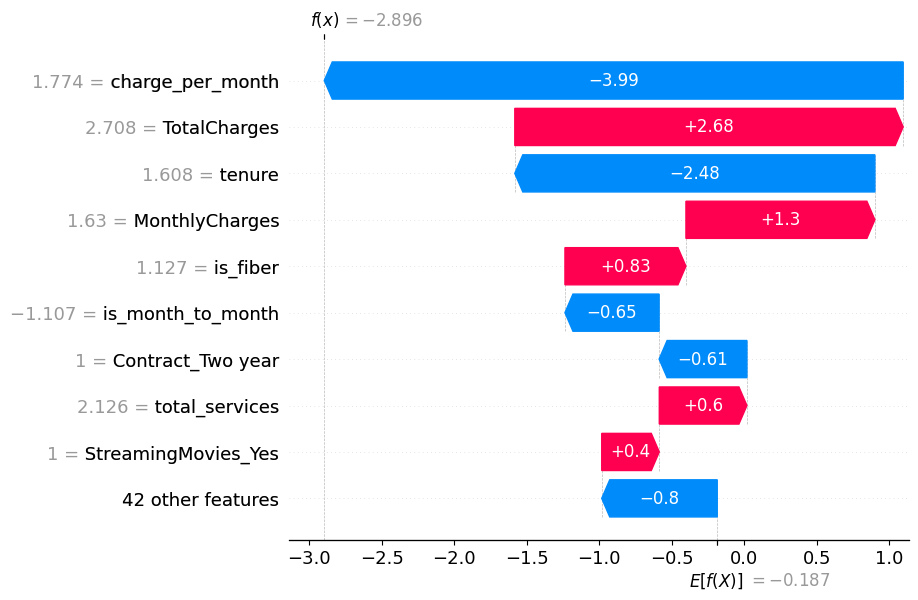

In [77]:
# SHAP decomposes a single prediction into feature-level contributions relative to a baseline (expected value).
# The model operates on preprocessed features (scaled/encoded)

import shap

i = 0

expl = shap.Explanation(
    values=shap_values[i],
    base_values=explainer.expected_value,
    data=X_test_proc[i],
    feature_names=all_features
)

shap.plots.waterfall(expl)

In [80]:
# After using a high-recall model (lower decision threshold), we now tighten the risk grouping
# to reduce false positives and improve precision in the "High risk" segment (business efficiency trade-off).

churn_scores = X_test.copy()
churn_scores['churn_probability'] = y_proba_tuned

# Lower thresholds = more strict High-risk definition (fewer false alarms, higher precision)
# Higher thresholds = more relaxed High-risk definition (captures more churners, higher recall)
churn_scores['risk_level'] = pd.cut(
    y_proba_tuned,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

top_risk = churn_scores[churn_scores['risk_level'] == 'High'].sort_values(
    'churn_probability', ascending=False
)

print(f"High risk customers flagged: {len(top_risk)}")

top_risk[['churn_probability', 'risk_level', 'tenure',
           'MonthlyCharges', 'is_month_to_month']].head(10)

High risk customers flagged: 604


,churn_probability,risk_level,tenure,MonthlyCharges,is_month_to_month
3380,0.999818,High,1,95.10,1
6866,0.999688,High,1,95.45,1
4585,0.999650,High,1,85.05,1
2397,0.999541,High,1,88.35,1
642,0.999536,High,1,89.55,1
6748,0.999481,High,1,85.00,1
5905,0.998997,High,1,85.00,1
346,0.998878,High,2,90.40,1
2246,0.998850,High,1,102.45,1
6623,0.998806,High,1,76.45,1


## 8b. High-Risk Customer Segmentation (K-Means Clustering)

Flagging customers as "High risk" is a start.
But the retention team can't give every at-risk customer the same intervention.

K-Means clustering groups high-risk customers by their feature profiles.
Each cluster represents a *distinct type of at-risk customer* 
and each type warrants a different retention strategy.

**Why K-Means here?**
We're not trying to predict anything — we're trying to *understand* the high-risk group.

**Choosing K=3:** Three segments maps to three practical retention levers:
contract offers, price interventions, and service upgrade pitches.

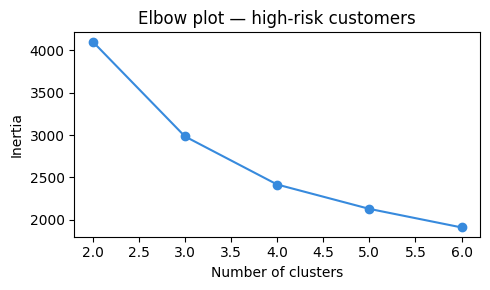

In [87]:
# Working only on high-risk customers
high_risk_idx = churn_scores[churn_scores['risk_level'] == 'High'].index
X_high_risk   = X_test.loc[high_risk_idx].copy()

# Scaling for clustering
scaler_cluster = StandardScaler()
X_hr_scaled = scaler_cluster.fit_transform(X_high_risk.select_dtypes('number'))

# Elbow check (quick)
inertias = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_hr_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(5, 3))
plt.plot(range(2, 7), inertias, marker='o', color='#378ADD')
plt.title('Elbow plot — high-risk customers')
plt.xlabel('Number of clusters'); plt.ylabel('Inertia')
plt.tight_layout(); plt.show()

In [89]:
# Fit K=3
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
X_high_risk['cluster'] = km.fit_predict(X_hr_scaled)
X_high_risk['churn_probability'] = churn_scores.loc[high_risk_idx, 'churn_probability'].values

# Profile each cluster
profile_cols = ['tenure', 'MonthlyCharges', 'is_month_to_month',
                'is_fiber', 'total_services', 'churn_probability']
cluster_profile = X_high_risk.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile['count'] = X_high_risk['cluster'].value_counts().sort_index()
print(cluster_profile)

         tenure  MonthlyCharges  is_month_to_month  is_fiber  total_services  \
cluster                                                                        
0         43.15           98.85               0.74       1.0            3.31   
1          8.46           48.01               0.95       0.0            1.28   
2         12.18           81.99               1.00       1.0            1.25   

         churn_probability  count  
cluster                            
0                     0.86    140  
1                     0.85    154  
2                     0.95    310  


In [90]:
# Segment labels derived from cluster means above
print("Segment labels:")
print("  Cluster 0 → Long-tenure high-spend fiber customers (satisfaction/price issue)")
print("  Cluster 1 → New uncommitted low-spend customers (haven't found value yet)")
print("  Cluster 2 → New high-spend fiber customers (highest risk — premium price, zero commitment)")
print()
print("Retention strategy:")
print("  Cluster 0 → Service quality review + loyalty reward")
print("  Cluster 1 → Onboarding support + contract upgrade incentive")
print("  Cluster 2 → Priority retention call + immediate discount or contract offer")

Segment labels:
  Cluster 0 → Long-tenure high-spend fiber customers (satisfaction/price issue)
  Cluster 1 → New uncommitted low-spend customers (haven't found value yet)
  Cluster 2 → New high-spend fiber customers (highest risk — premium price, zero commitment)

Retention strategy:
  Cluster 0 → Service quality review + loyalty reward
  Cluster 1 → Onboarding support + contract upgrade incentive
  Cluster 2 → Priority retention call + immediate discount or contract offer


## 8c. What-If Analysis — Quantifying the Value of an Intervention

The model is now useful for more than just flagging customers.
It can simulate the *impact of a retention intervention* before spending a dollar.

Here's the logic: if a high-risk customer is on a month-to-month contract,
what happens to their predicted churn probability if we successfully move them to an annual contract?

This directly answers: *"Is it worth offering a discount to lock in this customer?"*
If the probability drops significantly, the retention ROI is positive.

In [95]:
# Selecting a medium-high risk customer (70–85% range) — interventions are 
# most meaningful where the outcome is not yet certain
whatif_pool = churn_scores[
    (churn_scores['churn_probability'] >= 0.70) &
    (churn_scores['churn_probability'] <= 0.85) &
    (churn_scores['churn_probability'].notna())
]

customer_idx    = whatif_pool.index[0]
original_customer = X_test.loc[[customer_idx]].copy()
original_prob   = churn_scores.loc[customer_idx, 'churn_probability']


print("High-Risk Customer Profile")
print(f"Churn probability (current):  {original_prob:.2%}")
print(f"Contract:                     {original_customer['Contract'].values[0]}")
print(f"Monthly Charges:              ${original_customer['MonthlyCharges'].values[0]:.2f}")
print(f"Tenure (months):              {original_customer['tenure'].values[0]}")
print(f"Internet Service:             {original_customer['InternetService'].values[0]}")
print()

# Simulate realistic intervention — contract switch + one added service
intervened = original_customer.copy()
intervened['Contract']          = 'One year'
intervened['is_month_to_month'] = 0
intervened['fiber_x_mtm']       = 0
intervened['total_services']    = intervened['total_services'] + 1

# Reprocess and predict
intervened_proc = preprocessor.transform(intervened)
new_prob = lr_balanced.predict_proba(intervened_proc)[0, 1]

print("After Intervention: Contract Switch + One Added Service")
print(f"Churn probability (after):    {new_prob:.2%}")
print(f"Probability reduction:        {original_prob - new_prob:.2%}")
print()
annual_revenue = original_customer['MonthlyCharges'].values[0] * 12
print(f"Annual revenue at stake:      ${annual_revenue:,.2f}")
print(f"Expected value of retention:  ${annual_revenue * (original_prob - new_prob):,.2f}")
print()
print("→ A contract-switch + service bundle offer costs less than $346")
print("  to break even on this customer. Below that, retention is profitable.")

High-Risk Customer Profile
Churn probability (current):  82.44%
Contract:                     Month-to-month
Monthly Charges:              $78.20
Tenure (months):              18
Internet Service:             Fiber optic

After Intervention: Contract Switch + One Added Service
Churn probability (after):    45.49%
Probability reduction:        36.95%

Annual revenue at stake:      $938.40
Expected value of retention:  $346.73

→ A contract-switch + service bundle offer costs less than $346
  to break even on this customer. Below that, retention is profitable.


In [96]:
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model_final, f)

with open('churn_preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

# Save threshold separately — needed at inference time
with open('churn_threshold.pkl', 'wb') as f:
    pickle.dump(best_threshold, f)

print("churn_model.pkl saved")
print("churn_preprocessor.pkl saved")
print("churn_threshold.pkl saved")

churn_model.pkl saved
churn_preprocessor.pkl saved
churn_threshold.pkl saved


## 9. Business Insights

**Production model: class-weighted Logistic Regression, threshold = 0.35**
Recall improved from 0.79 to 0.89, reducing missed churners from 80 to 41
and recovering an additional $30,420 per cycle over the baseline.

**What the data showed:**
- Month-to-month contracts are the single strongest churn predictor
- The first 12 months is the highest-risk window — churn drops sharply after year one
- Fiber optic customers on month-to-month with no add-ons carry the highest combined risk
- Electronic check payment correlates with lowest customer commitment

**Three distinct high-risk segments identified:**
- Long-tenure high-spend fiber customers — likely a price or service quality issue
- New uncommitted low-spend customers — haven't found value yet
- New high-spend fiber customers — highest churn probability (0.95), most urgent to act on

**What-if analysis showed** that a contract switch combined with one added service
reduced a medium-high risk customer's churn probability from 82% to 45%,
with a retention break-even point of $346 — well within a typical retention budget.

## 10. Action Recommendations

**Now:** Call Cluster 2 customers first — new fiber users on month-to-month
are the highest risk and most responsive to a contract switch offer.

**Next 90 days:** Run the model weekly so the retention team gets a fresh
priority list before customers decide to leave, not after.

**Ongoing:** Retrain quarterly or when recall drops below 0.82.

## 11. Conclusions

A tuned Logistic Regression outperformed GBM even after full hyperparameter search 
simpler models generalise better when training and deployment distributions differ.

SMOTE-balanced training inflates CV scores for GBM; real performance is best read from the
held-out test set model had not seen. Probabilities should be treated as relative risk scores, not literal churn rates.

The model is a practical retention tool — not just a classifier. It identifies who
will churn, which segment they belong to, and whether an intervention is worth the cost.
Quarterly retraining is recommended as customer behaviour shifts over time.

## 12. Deployment Summary

The model, preprocessor, and threshold are saved and ready for integration.
The next step is wrapping these in a FastAPI endpoint so any internal system
can send a raw customer record and receive a churn risk score in real time.